In [1]:
import torch.backends.cudnn as cudnn
cudnn.benchmark = True

from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils


from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt

import os 

from file_management import get_version_folder, save_config, load_config
from CityScapes import CityscapesDataset
from stylegan import StyleGenerator, Discriminator


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
scale_for_display = lambda x: (x - torch.min(x)) / (torch.max(x) - torch.min(x))

In [2]:
load_run = None

In [3]:
if load_run:
    config_path = os.path.join(load_run,'stylegan_config.yaml')
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/stylegan'
    index_folder = get_version_folder(root)
    config = load_config('stylegan_config.yaml')
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,'stylegan_config.yaml')
    save_config(config, config_target_path)




Config saved to cache/stylegan/2/stylegan_config.yaml


In [4]:
channels = config["models"]["channels"]

z_dim = config["models"]['rec_gen']["z_dim"]
w_dim = config["models"]['rec_gen']["w_dim"]
mapping_network_depth = config["models"]['rec_gen']["mapping_network_depth"]
mapping_network_lr_mul  = config["models"]['rec_gen']["mapping_network_lr_mul"]


disc_block_depth = config["models"]["disc"]["block_depth"]
disc_residual = config["models"]["disc"]["residual"]

batch_size = config['training']['batch_size']

disc_lr = config['training']['disc']['disc_lr']
rec_gen_lr = config['training']['rec_gen']['rec_gen_lr']


save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')

Text(0.5, 1.0, 'Fake')

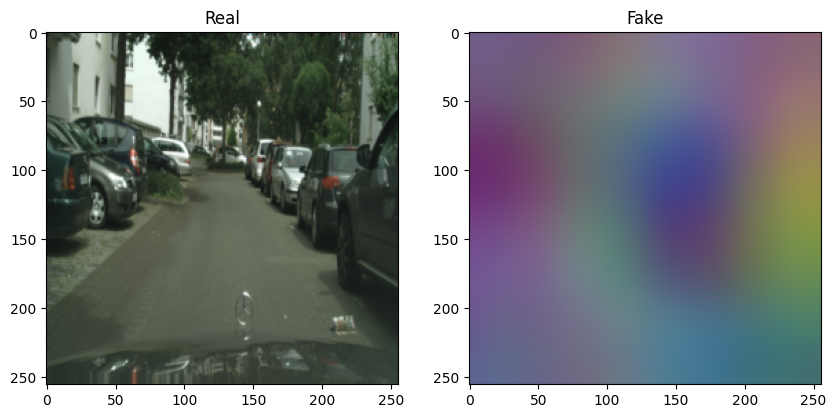

In [5]:

rec_gen = StyleGenerator(z_dim=z_dim,
                     w_dim=w_dim,
                     mapping_network_depth=mapping_network_depth,
                     mapping_network_lr_mul=0.01,
                     channels=channels,
                     img_channels=3).to(device)
disc = Discriminator(channels=channels,
                     block_depth=disc_block_depth,
                     residual=disc_residual,
                     img_channels=3).to(device)



rec_gen_optim = Adam(rec_gen.parameters(), lr=rec_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

z = torch.randn(batch_size, z_dim).to(device)
fake = rec_gen(z)
fake.shape


real,_ = next(iter(train_loader))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


fake =scale_for_display(fake)
ax[1].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('Fake')



In [ ]:
epochs = 10 

for epoch in range(0,epochs):
    loop = tqdm(train_loader)
    loop.set_description(f"Epoch {epoch}/{epochs}")
    for i, (real,_) in enumerate(loop):
        current_batch_size = real.shape[0]
        real = real.to(device)
        z_noise = torch.randn(current_batch_size,z_dim).to(device)

        disc_optim.zero_grad()
        with torch.no_grad():
            fake =rec_gen(z_noise)
            fake = fake.detach()
        disc_fake = disc(fake)
        disc_real = disc(real)

        disc_adv_loss = torch.mean(disc_fake) - torch.mean(disc_real)
        # disc_gp_loss =  10 * gradient_penalty(disc, real, fake, device)
        disc_loss_drift = 0.001 * (torch.mean(disc_real ** 2)+ torch.mean(disc_fake ** 2))

        disc_loss = disc_adv_loss  + disc_loss_drift
        disc_loss.backward()
        disc_optim.step()

        rec_gen_optim.zero_grad()
        z_noise = torch.randn(current_batch_size,z_dim).to(device)

        fake = rec_gen(z_noise)

        gen_fake = disc(fake)

        gen_adv_loss = -torch.mean(gen_fake)

        gen_loss = gen_adv_loss
        gen_loss.backward()
        rec_gen_optim.step()

        loop.set_postfix(loss_disc=disc_loss.item(),loss_gen=gen_loss.item())
        if (i+1) % save_itter == 0:
            torch.save(rec_gen.state_dict(), gen_path)
            torch.save(disc.state_dict(),disc_path)

            epoch_root= 'epoch_{}'.format(epoch)
            os.makedirs(os.path.join(samples_path,epoch_root),exist_ok=True)
        
            with torch.no_grad():
                noise = torch.randn(current_batch_size, z_dim).to(device)
                fake = rec_gen(noise) 

            fake =scale_for_display(fake)
            real =scale_for_display(real)
            imgs_to_plot = torch.cat([
                real,           # Top row: Real
                fake        # Bottom row: Fake
            ], dim=0)
            
           
            # Create a grid natively on the tensσors
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            
            # 1. Save to disk (replaces plt.savefig)
            img_path = os.path.join(samples_path, epoch_root, f'{i}.png')
            vutils.save_image(grid, img_path)
            
    


Epoch 0/10:  20%|██        | 128/625 [01:00<03:23,  2.44it/s, loss_disc=-473, loss_gen=448]  

Text(0.5, 1.0, 'Fake')

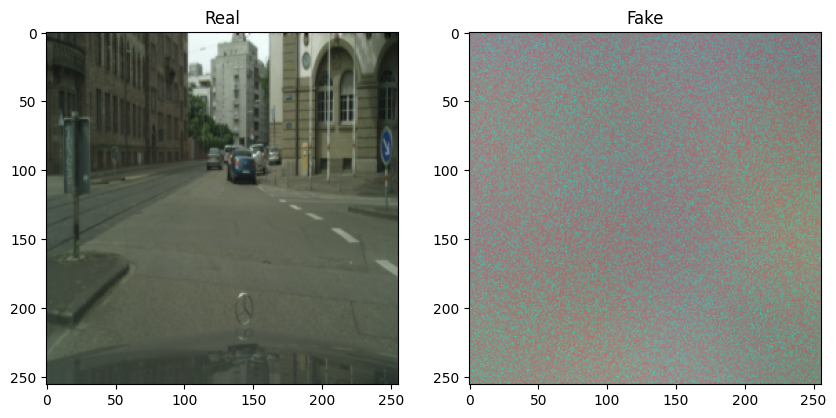

In [ ]:

z = torch.randn(batch_size, z_dim).to(device)
fake = rec_gen(z)
fake.shape


real,_ = next(iter(train_loader))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


fake =scale_for_display(fake)
ax[1].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('Fake')

